# Denoising Autocorrelation and Decorrelation Scale Testing  

**Purpose**: Code for testing the Autocorrelation and decorrelation scale functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from collections import defaultdict
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2
from scipy.ndimage import uniform_filter1d

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series,windowed_decorrelation_scale
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, compute_amp_phase, compute_amp_phase_unc, detrend
from structure_functions import compute_structure_function
from plotScaleAnalysis import month_fmt

Set data analysis parameters

In [3]:
# Set processing parameters
option_mooring       = 'CCE2' # Specifies which mooring will analyzed. 
option_obs           = 'ADCP' # Specifies the observational instrumentation to process. Options include: 'CTD', 'CHL', 'ADCP'
option_grid          = 0      # Specifies whether the gridded product or the nearest neighbor depth-correct approach approach is used
option_plot          = 0

# Set time and space parameters
T               = 1*(60)*(60)                         # Spcifies the time interval for model run. Units: seconds
estimator       = 'biased'                            # Specifies the approach for estimating the autocorrelation function  
start_time      = datetime(2014, 1, 1, 0, 0, 0)       # Specifies the start time of the event period  datetime(2016, 1, 1, 0, 0, 0) datetime(2025, 3, 12, 0, 0, 0)
end_time        = datetime(2015, 12, 31, 23, 59, 59)  # Specifies the end time of the event period        datetime(2025, 12, 31, 23, 59, 59)  datetime(2025, 6, 23, 0, 0, 0) 
event_time_bnds = [start_time, end_time]              # Specifies the event period

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 14

# Set font and fontsize
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load CCE processed data

In [4]:
# Set the file name and read in the data file
if option_grid == 1:
    filename_CCE = PATH + "/data/CCE/" + option_mooring + "/" + option_obs + "/" + option_mooring + "_" + option_obs + "_" + str(start_time.year) + str(start_time.month) + str(start_time.day) +  "-" + str(end_time.year) + str(end_time.month) + str(end_time.day) + "_intermediate_gridded_data.nc"
else:
    filename_CCE = PATH + "/data/CCE/" + option_mooring + "/" + option_obs + "/" + option_mooring + "_" + option_obs + "_" + str(start_time.year) + str(start_time.month) + str(start_time.day) +  "-" + str(end_time.year) + str(end_time.month) + str(end_time.day) + "_intermediate_data.nc"
nc_CCE = Dataset(filename_CCE, 'r')

# Extract data variables
depth           = nc_CCE.variables['depth'][:]
time            = num2date(nc_CCE.variables['time'][:], nc_CCE.variables['time'].units)
time_daily      = num2date(nc_CCE.variables['time_daily'][:], nc_CCE.variables['time_daily'].units)
lon             = nc_CCE.variables['LON'][:]
lat             = nc_CCE.variables['LAT'][:]

U               = nc_CCE.variables['U'][:]
V               = nc_CCE.variables['V'][:]
U_depth         = nc_CCE.variables['U_depth'][:]
V_depth         = nc_CCE.variables['V_depth'][:]
U_daily         = nc_CCE.variables['U_daily'][:]
V_daily         = nc_CCE.variables['V_daily'][:]

U_shelf               = nc_CCE.variables['U_shelf'][:]
V_shelf               = nc_CCE.variables['V_shelf'][:]
U_shelf_depth         = nc_CCE.variables['U_shelf_depth'][:]
V_shelf_depth         = nc_CCE.variables['V_shelf_depth'][:]
U_shelf_daily         = nc_CCE.variables['U_shelf_daily'][:]
V_shelf_daily         = nc_CCE.variables['V_shelf_daily'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])
time_daily_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time_daily])

Compute the decorrelation scale for the entire record signal depth

In [7]:
# Set parameters
ndepth,ntime = np.shape(U_shelf)
norm = 1
lag = int(ntime/4)
w1, w2 = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
M = 20                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'

# Compute the elapsed time from beginning of segmented time series (units: seconds)
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Set the variable to plot 
data = U_shelf

#--- Along-shore 12-hourly Velocity --- #

# Initialize arrays 
autocorr_u       = np.zeros((lag,ndepth))
time_scale_u     = np.zeros((lag,ndepth))
L_t_u            = np.zeros((ndepth))
S_u              = np.zeros((nfft,ndepth))
CI_u             = np.zeros((nfft,2,ndepth))

# Set counter
cn_depth = 0 

# Loop through depths 
for idepth in range(0,1): #ndepth):
    
    # Set progress bar
    progress = (idepth) / (len(depth))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
            
    # Initialize the ith time series 
    data_ts = data[idepth,:]

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Detrend data record 
    data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

    # Compute frequency power spectrum 
    data_interp = np.interp(time_elapsed, time_elapsed[~data_dt.mask], data_dt[~data_dt.mask])
    S_u[:,cn_depth], f_u, CI_u[:,:,cn_depth], _ = spectrum1D_frequency(data_interp, T, M, units)

    # Compute autocorrelation function
    autocorr_u[:,cn_depth], _, _, _, time_scale_u[:,cn_depth], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, norm)

    # Compute the decorrelation scale
    L_t_u[cn_depth] = compute_decor_scale_optimize(autocorr_u[:,cn_depth],time_scale_u[:,cn_depth],T,'unbiased',norm)

    # Convert frequency and time scale to cycles per day and days respectively  
    f_cpd = f_u * (60*60*24)
    time_scale_days = time_scale_u[:,cn_depth] * (1/60) * (1/60) * (1/24)

    # Plot Spectral slope 
    if option_plot == True: 
            
            ##################################
            #--- Autocorrelation Function ---# 
            ##################################

            # Create Figure 
            fig, ax = plt.subplots(figsize=(8,6))

            # Plot Autocorrelation function
            ax.plot(time_scale_days, autocorr_u[:,cn_depth], 'k.-', lw = 1)

            # Set figure attributes
            ax.set_xlabel('Time Lag (days)')
            ax.set_ylabel('Autocorrelation')
            ax.grid(True, ls='--', alpha=0.3)
            ax.set_xlim(0,10)

            # Display figure 
            plt.tight_layout()
            plt.show()

            ##################################
            #--- PSD Function ---# 
            ##################################
            
            # Create Figure 
            fig, ax = plt.subplots(figsize=(8,6))

            # Plot PSD function 
            ax.loglog(f_cpd[1:], S_u[1:,cn_depth], 'b.-', lw=1)

            # Plot 95% confidence intervals
            ax.fill_between(f_cpd[1:], CI_u[1:,0,cn_depth], CI_u[1:,1,cn_depth], color='tab:blue', alpha=0.2)

            # Set figure attributes 
            ax.set_xlabel('Frequency [Hz]')
            ax.set_ylabel('PSD')
            ax.grid(True, which='both', ls='--', alpha=0.3)

            # Display figure
            plt.tight_layout()
            plt.show()

    # Set longitude counter
    cn_depth = cn_depth + 1

# Convert time scale to units of days
Lt_u = L_t_u*(1/60)*(1/60)*(1/24)

# Display Decorrelation scale
print(Lt_u[0])


Progress: 0.0%6.0813474467301925


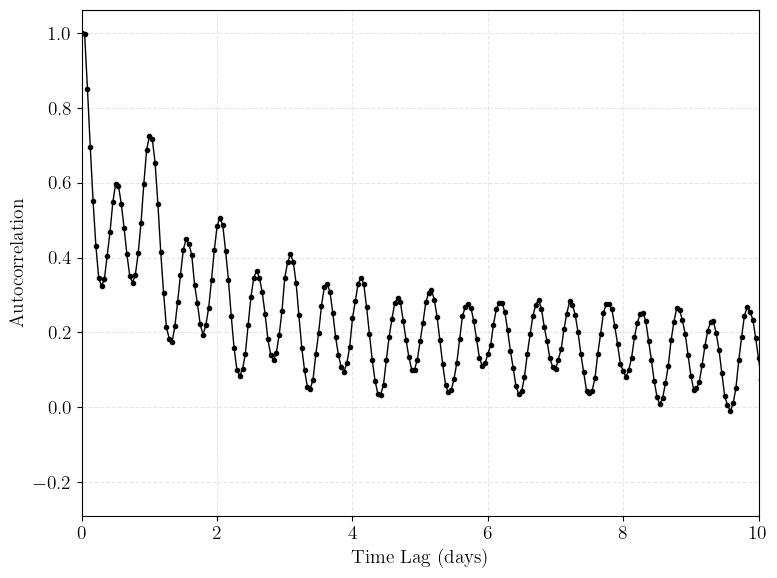

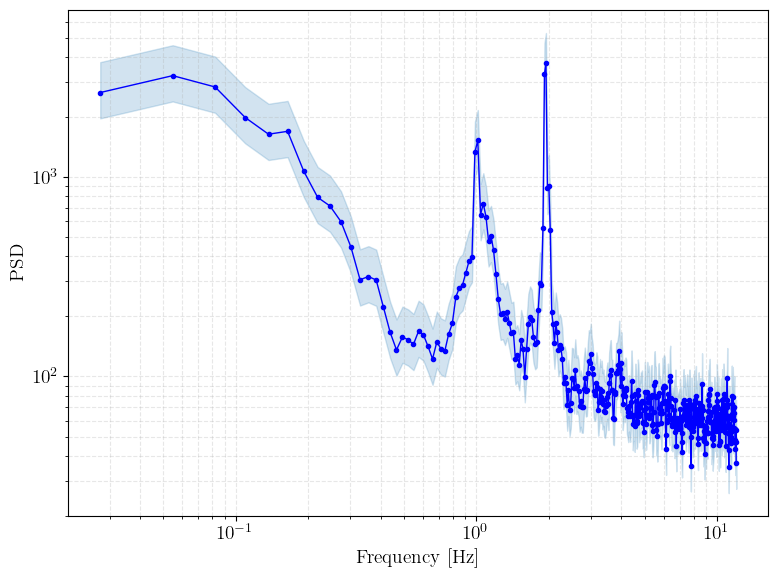

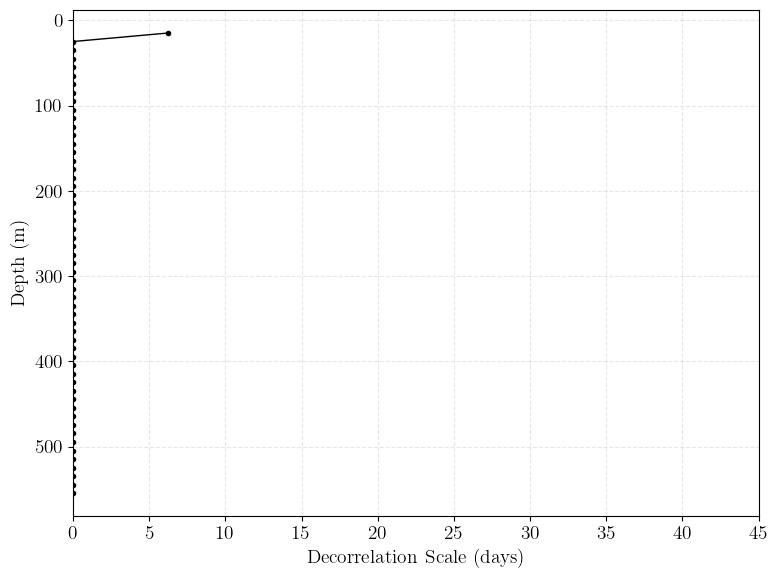

In [13]:
option_plot = True
cn_depth = 0

# Plot Spectral slope 
if option_plot == True: 
        
        ##################################
        #--- Autocorrelation Function ---# 
        ##################################

        # Create Figure 
        fig, ax = plt.subplots(figsize=(8,6))

        # Plot Autocorrelation function
        ax.plot(time_scale_days, autocorr_u[:,cn_depth], 'k.-', lw = 1)

        # Set figure attributes
        ax.set_xlabel('Time Lag (days)')
        ax.set_ylabel('Autocorrelation')
        ax.grid(True, ls='--', alpha=0.3)
        ax.set_xlim(0,10)

        # Display figure 
        plt.tight_layout()
        plt.show()

        ##################################
        #--- PSD Function ---# 
        ##################################
        
        # Create Figure 
        fig, ax = plt.subplots(figsize=(8,6))

        # Plot PSD function 
        ax.loglog(f_cpd[1:], S_u[1:,cn_depth], 'b.-', lw=1)

        # Plot 95% confidence intervals
        ax.fill_between(f_cpd[1:], CI_u[1:,0,cn_depth], CI_u[1:,1,cn_depth], color='tab:blue', alpha=0.2)

        # Set figure attributes 
        ax.set_xlabel('Frequency [Hz]')
        ax.set_ylabel('PSD')
        ax.grid(True, which='both', ls='--', alpha=0.3)

        # Display figure
        plt.tight_layout()
        plt.show()

##################################
#--- Decorrelation Scale Profile ---# 
##################################

# Create Figure 
fig, ax = plt.subplots(figsize=(8,6))

# Plot Autocorrelation function
ax.plot(Lt_u, depth, 'k.-', lw = 1)

# Set figure attributes
ax.set_xlabel('Decorrelation Scale (days)')
ax.set_ylabel('Depth (m)')
ax.grid(True, ls='--', alpha=0.3)
ax.set_xlim(0,45)
ax.invert_yaxis()

# Display figure 
plt.tight_layout()
plt.show()
